
# ICS - Travaux Pratiques 11

15.05.25


<font color=grey>_Ce 11e TP se concentre sur la méthode de Newton ainsi que sur les méthodes de point fixe._ 

_Note : ne vous sentez pas obligé.e.s de finir la série pendant la séance! Celle-ci est conçue de manière à ce que vous gardiez certains exercices pour vos révisions._ </font>

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

***

## Exercice 1 : Newton

Dans cet exercice, il vous est proposé de déterminer numériquement les zéros de la fonction 
$f(x)=(x+1)^2(x-\frac{3}{2})$. 

Pour ce faire, implémentez la **méthode de Newton** présentée en cours en définissant une fonction `resoudre_par_Newton`$\dots$
* $\dots$ dont les arguments sont la fonction `f` étudiée, le point de départ `x_0` de la méthode, la fonction dérivée `fprime`, la tolérance `eps` et le nombre maximum d'itérations autorisées `k_max` ;
* $\dots$ qui calcule par itérations une approximation d'un zéro de $f$ ;
* $\dots$ qui s'arrête :
    - soit quand la valeur absolue de $f(x_k)$ est inférieure à la tolérance ; 
    - soit quand le nombre maximum d'itérations est atteint ; 
    - si la valeur de la dérivée utilisée à chaque itération est inférieure à `1e-10` pour éviter tout problème de divergence dans la formule utilisée ;
* $\dots$ qui retourne une valeur approchée d'un zéro de $f$, ainsi qu'une liste de tuples, ces tuples contenant les couples $(x_k,f(x_k))$ utilisés à chaque itération $k$. 

Testez votre implémentation en recherchant les deux zéros de la fonction $f$ avec une tolérance de $10^{-8}$. Expérimentez l'efficacité de la méthode selon le point de départ $x_0$ choisi et selon la nature du zéro considéré. Constatez-vous des différences notables ? Si oui, essayez d'en expliquer la raison, notamment en vous basant sur le graphe de cette fonction.

Représentez graphiquement la différence
$$
x_{k} - x_{k-1}
$$
en fonction des itérations. Quelles conclusions peut-on tirer de la comparaison de cette différence à la dernière itération avec la tolérance (sur $f(x_k)$) que nous avons considérée ?

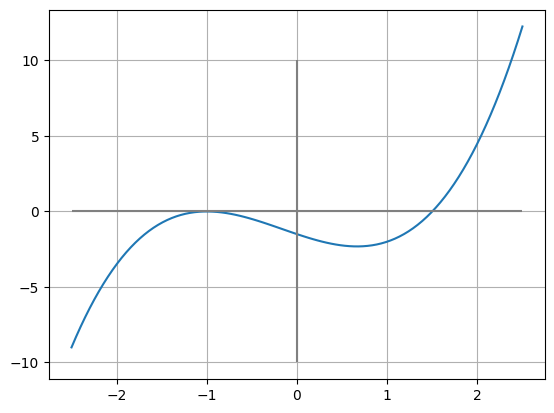

In [ ]:
# Commencez par représenter graphiquement la fonction !
def f(x):
    return np.pow(x+1, 2)*(x-3/2)


def fprime(x):
    return 3 * np.pow(x, 2) + x - 2


x = np.linspace(-2.5, 2.5, 100)
y = f(x)

plt.plot(x, y)
plt.hlines(0, -2.5, 2.5, color="grey")
plt.vlines(0, -10, 10, color="grey")
plt.grid()
plt.show()

In [3]:
# Implémentation de la méthode de Newton
def resoudre_par_Newton(f, x_0, fprime, eps, k_max):
    x_k = x_0
    k = 1
    coord = []
    while np.abs(f(x_k)) >= eps and k < k_max and fprime(x_k) >= 1e-10:
        x_k = x_k - (f(x_k)/fprime(x_k))
        coord.append((x_k, f(x_k)))
        k += 1
    return (x_k, coord)

In [11]:
# recherche du premier zéro de la fonction f
zero_1 = resoudre_par_Newton(f, -2, fprime, 10 ** (-8), 20)
zero_1_x_k, zero_1_lst = zero_1
zero_1

(np.float64(-1.0000415981568678),
 [(np.float64(-1.5625), np.float64(-0.968994140625)),
  (np.float64(-1.3049065420560748), np.float64(-0.2607665496869294)),
  (np.float64(-1.160312307910976), np.float64(-0.06837012226477429)),
  (np.float64(-1.0825006469158485), np.float64(-0.0175774206881503)),
  (np.float64(-1.0418988564950138), np.float64(-0.004462339475492396)),
  (np.float64(-1.021120674648049), np.float64(-0.0011246288157178812)),
  (np.float64(-1.0106043873934722), np.float64(-0.00028232507549188417)),
  (np.float64(-1.0053133679025708), np.float64(-7.072970252705435e-05)),
  (np.float64(-1.0026594981673531), np.float64(-1.770113670109472e-05)),
  (np.float64(-1.001330455249898), np.float64(-4.427632983654905e-06)),
  (np.float64(-1.0006654044948757), np.float64(-1.1072024710867899e-06)),
  (np.float64(-1.000332746506082), np.float64(-2.7683743504666346e-07)),
  (np.float64(-1.0001663843228545), np.float64(-6.921396337022488e-08)),
  (np.float64(-1.0000831949295252), np.float64

In [12]:
# recherche du second zéro de la fonction f
zero_2 = resoudre_par_Newton(f, 2, fprime, 10 ** (-8), 20)
zero_2_x_k, zero_2_lst = zero_2
zero_2

(np.float64(1.5),
 [(np.float64(1.625), np.float64(0.861328125)),
  (np.float64(1.5108695652173914), np.float64(0.06852680406016305)),
  (np.float64(1.5000933009889905), np.float64(0.0005831747073756688)),
  (np.float64(1.50000000696328), np.float64(4.352049994645583e-08)),
  (np.float64(1.5), np.float64(0.0))])

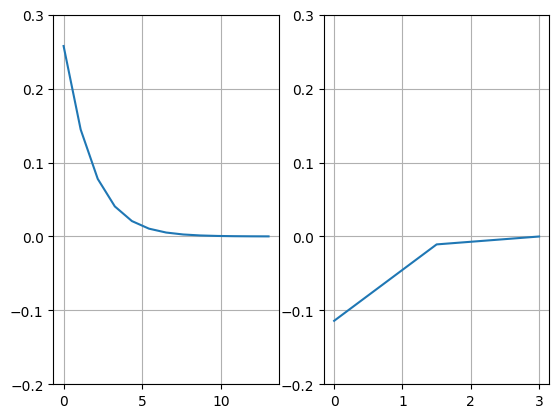

In [36]:
# Représentation de la convergence et de la différence x_k - x_{k-1}
def diff(zero):
    diff = []
    for i in range(1, len(zero) - 1):
        diff.append(zero[i][0] - zero[i-1][0])
    return diff


diff_1 = diff(zero_1_lst)
x_1 = np.linspace(0, len(diff_1), len(diff_1))

diff_2 = diff(zero_2_lst)
x_2 = np.linspace(0, len(diff_2), len(diff_2))

fig, ax = plt.subplots(1, 2)

ax[0].grid()
ax[0].plot(x_1, diff_1)
ax[0].set(ylim=(-.2, .3))

ax[1].grid()
ax[1].plot(x_2, diff_2)
ax[1].set(ylim=(-.2, .3))

plt.show()

***

## Exercice 2 : k-contraction

Les fonctions de $\mathcal{R}$ dans $\mathcal{R}$, $\displaystyle f(x)=\frac{\cos{(x)}+x}{4}$ et $\displaystyle g(x)=\frac{\cos{(x)}+x^2}{4}$ sont-elles **$K$-contractantes** sur tout intervalle $I$ contenu dans $\mathcal{R}$?

En cas de réponse négative, essayez de trouver un intervalle autour de l'origine dans lequel la fonction est $K$-contractante.

In [ ]:
# Représentation graphique des fonctions


***

## Exercice 3 : Points fixes

Dans cet exercice, il vous est demandé d'étudier les quatre fonctions suivantes :
$$
f(x) = 1-\sin{(x)}\,,~~~~
g(x) = \exp{(-4x)}\,,~~~~
h(x) = 0.4 \exp{(x)}-0.25\,~~~~\hbox{et}~~~~
i(x) = \displaystyle\frac{1}{1+\left(\frac{1-x}{x}\right)^2}\,,
$$
sur l'intervalle ouvert $I=\,]0,1[$.

Pour chacune de ces fonctions, vous devez en particulier $\dots$
- $\dots$ vérifier graphiquement l'existence d'un **unique point fixe** sur $I$ (en représentant la **fonction "identité"** $y(x)=x$) ;
- $\dots$ choisir deux valeurs différentes pour le point de départ $x_0$ et d'effectuer un certain nombre d'**itérations de la méthode de Picard** (en les représentant graphiquement sur la même figure) ;
- $\dots$ déterminer la nature du point fixe (**répulsif** ou **attracteur**) ;
- $\dots$ expliquer vos observations en vous intéressant au **comportement de la dérivée** et à sa valeur aux alentours du point fixe.

C:\Users\berre\AppData\Local\Temp\ipykernel_37984\751226928.py:15: RuntimeWarning: divide by zero encountered in divide
  return 1/(1+((1-x)/x)**2)


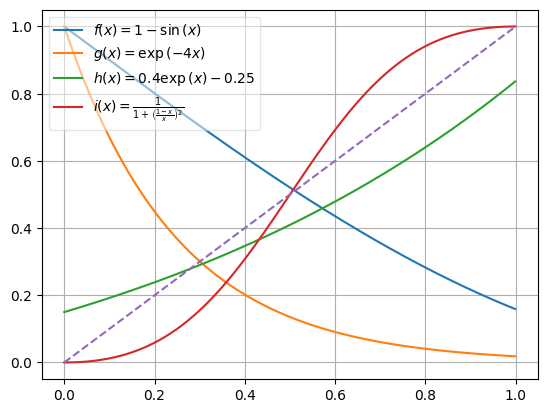

In [45]:
# Représentation graphique de l'existence d'un point fixe
def f(x):
    return 1 - np.sin(x)


def g(x):
    return np.exp(-4*x)


def h(x):
    return 0.4*np.exp(x)-0.25


def i(x):
    return 1/(1+((1-x)/x)**2)


x = np.arange(0, 1, 0.001)

plt.plot(x, f(x), label=r"$f(x) = 1-\sin{(x)}$")
plt.plot(x, g(x), label=r"$g(x) = \exp{(-4x)}$")
plt.plot(x, h(x), label=r"$h(x) = 0.4 \exp{(x)}-0.25$")
plt.plot(x, i(x), label=r"$i(x) = \frac{1}{1+\left(\frac{1-x}{x}\right)^2}$")
plt.plot(x, x, linestyle="--")

plt.grid()
plt.legend(loc="upper left", framealpha=.5)
plt.show()

In [46]:
# Représentation graphique (ou sur papier) de la méthode de Ricard
# appliquée aux fonctions présentées.
'''
f(x) -> attracteur
g(x) -> répulsif
h(x) -> attracteur
i(x) -> attracteur
'''

'\nf(x) -> attracteur\ng(x) -> répulsif\nh(x) -> attracteur\ni(x) -> attracteur\n'

***

## Exercice 4 : Fonction d'itération

Soit $f(x)$ une fonction dont on cherche les zéros. Laquelle des fonctions $\Phi(x)$ suivantes est-elle, a priori, acceptable comme fonction d’itération ? Justifiez votre réponse. -> La e), car elle est sous la forme $\Phi(x) = x + F(f(x))$, avec $F(f(x)) = (x + 1)f(x)$  <br/><br/>
&nbsp;   a) $\Phi(x) = f(x)/x$ -> NON   <br/><br/>
&nbsp;   b) $\Phi(x) = (x + 1)f(x)$ -> NON  <br/><br/>
&nbsp;   c) $\Phi(x) = 5f(x) + x^2 + x$   <br/><br/>
&nbsp;   d) $\Phi(x) = (x + 1) [f (x) + 1]$   <br/><br/>
&nbsp;   e) $\Phi(x) = (x + 1)f(x) + x$  

***

## Exercice 5 : Méthode de Picard

Reprenons les fonctions de l'exercice 2

$$
\displaystyle f(x)=\frac{\cos{(x)}+x}{4}~~~\hbox{et}~~~
\displaystyle g(x)=\frac{\cos{(x)}+x^2}{4}.
$$

Nous avons montré (n'est-ce pas) qu'elles sont $K$-contractantes sur $\mathcal{R}$ dans le cas de $f(x)$ et sur, par exemple, 
$I_\pi=\displaystyle\left]-\frac{\pi}{2},\frac{\pi}{2}\right[$ dans le cas de $g(x)$.

Dans cet exercice, il vous est demandé de :

a) vérifier que la fonction $f$ admet un unique point fixe et que la suite $\{x_k\}$ obtenue par la méthode de Picard converge vers ce point fixe quel que soit le point de départ $x_0$ de la méthode :
   * représentez graphiquement la fonction $f$ ;
   * vérifiez "visuellement" l'existence d'un unique point fixe ;
   * trouvez une valeur approchée à 5 décimales de ce point fixe grâce à la méthode de Picard, en testant votre implémentation avec différentes valeurs de départ $x_0$.

b) vérifier de manière analogue le théorème du point fixe du cours dans le cas particulier de la fonction $g$ sur $I_\pi$. Ce théorème s'applique-t-il dans le cas de cette fonction sur l'intervalle $\displaystyle\left]-\frac{\pi}{2},0\right[$ ?

In [ ]:
# a)


In [ ]:
# b)
